In [6]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 29s 0us/step


C:\Users\SivaGuduri\Desktop\learn-ML\dl-env\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


## Step 1 — Check shapes
Meaning:
50,000 images
each image = 32×32
3 channels = RGB

In [7]:
print(X_train.shape)
print(y_train.shape)

(50000, 32, 32, 3)
(50000, 1)


## Step 2 — Keep only cats and dogs
CIFAR has 10 classes.
We only keep: 3 = cat, 5 = dog

In [8]:
train_mask = np.where((y_train == 3) | (y_train == 5))[0]
test_mask = np.where((y_test == 3) | (y_test == 5))[0]

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

## Step 3 — Convert labels to binary
Now:
0 = cat
1 = dog

In [9]:
y_train = (y_train == 5).astype(int)
y_test = (y_test == 5).astype(int)

## Step 4 — Normalize

In [10]:
X_train = X_train / 255.0
X_test = X_test / 255.0

## Step 5 — Visualize samples

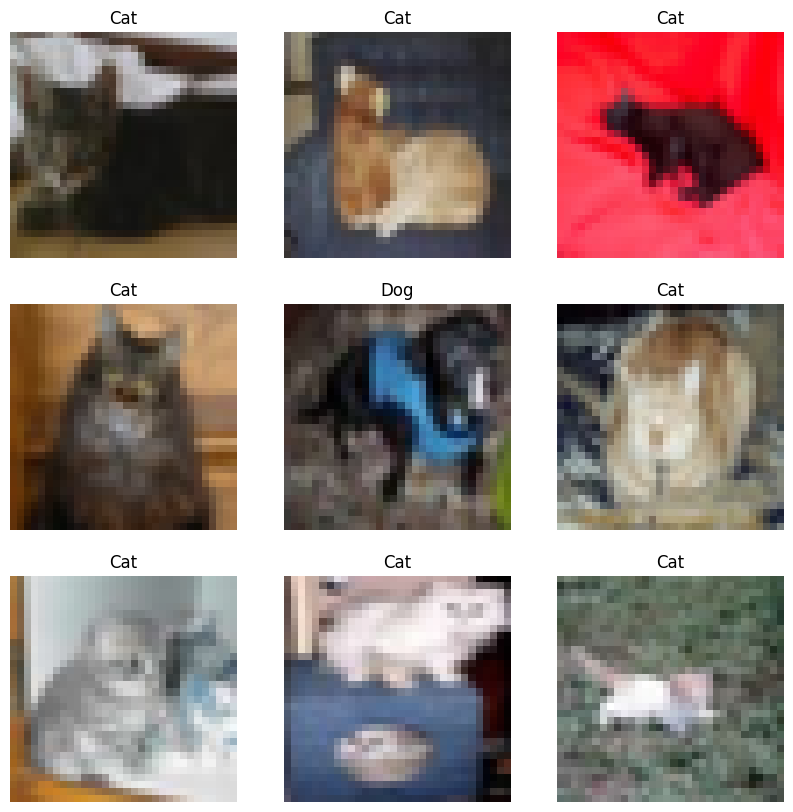

In [11]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.title("Dog" if y_train[i] == 1 else "Cat")
    plt.axis("off")

plt.show()

## Step 6 Build Cat vs Dog CNN
Why Dense(1)?
Only two classes. One neuron enough.
Decision:

< 0.5 → cat
> 0.5 → dog

In [19]:
# OLD MODEL
# model = tf.keras.models.Sequential([
#     tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
#     tf.keras.layers.MaxPooling2D((2,2)),

#     tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
#     tf.keras.layers.MaxPooling2D((2,2)),

#     tf.keras.layers.Conv2D(128, (3,3), activation="relu"),

#     tf.keras.layers.Flatten(),

#     tf.keras.layers.Dense(128, activation="relu"),

#     tf.keras.layers.Dense(1, activation="sigmoid")
# ])

In [21]:
model = tf.keras.models.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),

    tf.keras.layers.Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation="sigmoid")
])

## Step 7 Compile

In [22]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Step 8 Train

In [24]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7471 - loss: 0.5080 - val_accuracy: 0.7635 - val_loss: 0.4804
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.7562 - loss: 0.4942 - val_accuracy: 0.7770 - val_loss: 0.4716
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7688 - loss: 0.4820 - val_accuracy: 0.7790 - val_loss: 0.4748
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.7625 - loss: 0.4792 - val_accuracy: 0.7800 - val_loss: 0.4686
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7712 - loss: 0.4762 - val_accuracy: 0.7800 - val_loss: 0.4641
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7722 - loss: 0.4691 - val_accuracy: 0.7695 - val_loss: 0.4844
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7781 - loss: 0.4576 - val_accuracy: 0.7765 - val_loss: 0.4665
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7797 - loss: 0.4607 - val_accu

## Predict and Test

In [25]:
predictions = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


[0.09241599]
[0]


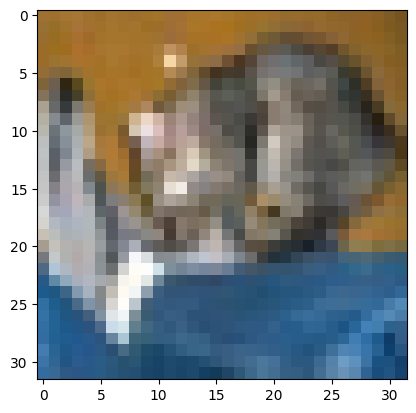

In [27]:
print(predictions[0])
print(y_test[0])

plt.imshow(X_test[0])
plt.show()

## final training accuracy
## final validation accuracy

In [28]:
print(history.history["accuracy"][-1])
print(history.history["val_accuracy"][-1])

0.7847999930381775
0.7889999747276306


## Test one image

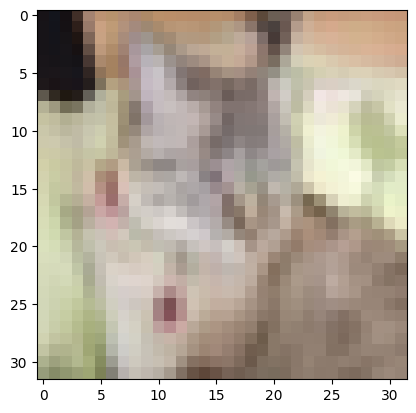

Predicted: Cat
Actual: Cat


In [30]:
index = 1

plt.imshow(X_test[index])
plt.show()

pred = predictions[index][0]

if pred > 0.5:
    print("Predicted: Dog")
else:
    print("Predicted: Cat")

print("Actual:", "Dog" if y_test[index] == 1 else "Cat")